In [28]:
#pip install lightgbm


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from lightgbm import LGBMRegressor

In [30]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_change_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [31]:
# 2. FEATURE ENGINEERING (Lag 1)
features = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target = 'Gold'

# Tạo các cột lag1
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

df.dropna(inplace=True)

In [32]:
# 3. CHUẨN BỊ DỮ LIỆU TRAIN/TEST
X = df[[f'{col}_lag1' for col in features]]
y = df[target]

split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [33]:
# 4. KHỞI TẠO MÔ HÌNH LightGBM
model_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)


In [34]:
# 5. TRAIN
model_lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 142288, number of used features: 5
[LightGBM] [Info] Start training from score 0.215865


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [35]:
# 6. DỰ ĐOÁN
y_pred = model_lgb.predict(X_test)

In [36]:
# 7. ĐÁNH GIÁ MÔ HÌNH
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.02771495863737384
R² Score: 0.48293026435489117


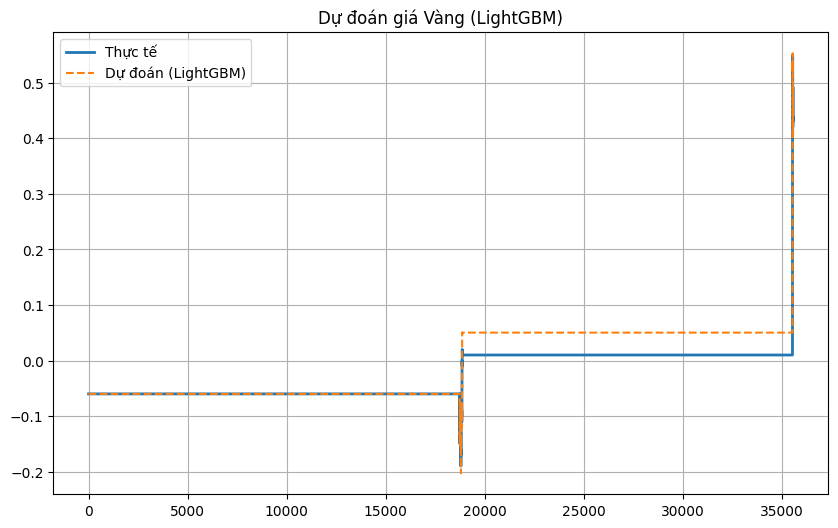

In [37]:
# 8. VẼ ĐỒ THỊ DỰ ĐOÁN
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Thực tế', linewidth=2)
plt.plot(y_pred, label='Dự đoán (LightGBM)', linestyle='--')
plt.title("Dự đoán giá Vàng (LightGBM)")
plt.legend()
plt.grid(True)
plt.show()

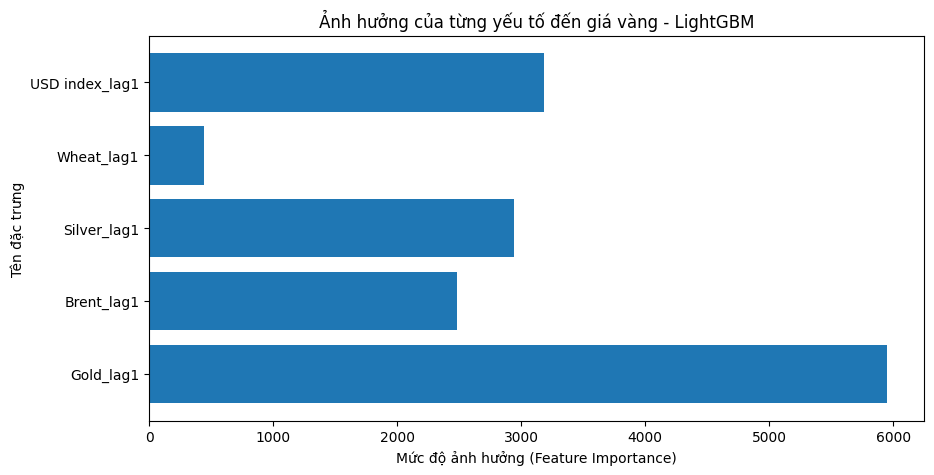

In [38]:
# 9. FEATURE IMPORTANCE
importance = model_lgb.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, importance)
plt.xlabel("Mức độ ảnh hưởng (Feature Importance)")
plt.ylabel("Tên đặc trưng")
plt.title("Ảnh hưởng của từng yếu tố đến giá vàng - LightGBM")
plt.show()

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# 1. Load data gốc (để lấy thông tin min/max của giá Vàng thật)
# Bạn sửa lại đường dẫn đúng tới file data sạch của bạn
path_data = '../../data/raw/data_price_realtime.csv' # Hoặc file data_final của bạn
df_raw = pd.read_csv(path_data, parse_dates=['Datetime'], index_col='Datetime')

# 2. Tạo một Scaler riêng chỉ cho cột Gold (Target)
# Việc này giúp việc inverse_transform không bị lỗi kích thước
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df_raw[['Gold']]) # Học min/max của cột Gold

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [40]:
# 3. Đảo ngược chuẩn hóa (Đưa về giá USD)
# reshape(-1, 1) giúp biến mảng 1 chiều thành cột dọc để scaler hiểu
pred_usd = target_scaler.inverse_transform(y_pred.reshape(-1, 1))
actual_usd = target_scaler.inverse_transform(y_test.values.reshape(-1, 1))

# 4. Tạo DataFrame kết quả
# Lưu ý: y_test.index chính là thời gian thực của tập test
result_df = pd.DataFrame({
    'Datetime': y_test.index,
    'Actual': actual_usd.flatten(),      # Giá thực (USD)
    'Predicted': pred_usd.flatten()      # Giá dự báo (USD)
})

# 5. Lưu ra file CSV (Nhớ thay đổi tên file cho đúng model: xgb, rf, linear, lgbm...)
save_path = '../../results/predictions/LGBM.csv' # <--- SỬA TÊN FILE Ở ĐÂY
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"✅ Đã lưu kết quả (USD) vào: {save_path}")
print(result_df.tail())

✅ Đã lưu kết quả (USD) vào: ../../results/predictions/LGBM.csv
                 Datetime     Actual    Predicted
35568 2025-12-18 23:57:00  4247.2939  4242.172026
35569 2025-12-18 23:57:10  4251.3485  4242.172026
35570 2025-12-18 23:57:20  4257.4304  4259.853170
35571 2025-12-18 23:57:30  4259.4577  4259.853170
35572 2025-12-18 23:57:40  4259.4577  4259.853170
